# 05 — RAG Retrieval: Similar Report Injection

**Idea:** At inference time, retrieve the top-k most similar training reports and inject them
as few-shot examples in the prompt. The model generates conditioned on:
1. The chest X-ray image
2. The clinical indication
3. k reference reports from semantically similar cases

**Retrieval strategy:** TF-IDF over clinical indications (CPU-only, no GPU required for indexing).  
Saves `reports/eval_hypotheses_rag_k{K}_{VARIANT}.json` and `reports/eval_metrics_rag_k{K}_{VARIANT}.json`
so notebook 04 STEP 7 can include RAG in the grand comparison.

**Run after notebook 04** (needs `eval_hypotheses_uniform_v3.json` cached references).

**Execution order across notebooks:**
```
04 (core eval)  →  [this notebook]  →  06 (assoc. rules)  →  04 STEP 7 (grand comparison)
```

## STEP 1 — Environment setup

In [1]:
import os, sys, json, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import yaml

matplotlib.rcParams['figure.dpi'] = 120
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

PROCESSED_DIR  = REPO_ROOT / 'data' / 'processed'
CHECKPOINT_DIR = REPO_ROOT / 'checkpoints'
FIGURES_DIR    = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(REPO_ROOT / 'params.yaml') as f:
    params = yaml.safe_load(f)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {props.name}  {props.total_memory/1e9:.1f} GB')

test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
test_df = test_df[test_df['findings'].notna() & (test_df['findings'].str.strip() != '')].reset_index(drop=True)
references = test_df['findings'].str.strip().tolist()
print(f'Test set : {len(test_df)} studies')

train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
train_df = train_df[train_df['findings'].notna() & (train_df['findings'].str.strip() != '')].reset_index(drop=True)
print(f'Train set: {len(train_df)} studies')

env_file = REPO_ROOT / '.env'
if env_file.exists():
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())
    import huggingface_hub
    hf_token = os.environ.get('HF_TOKEN')
    if hf_token:
        huggingface_hub.login(token=hf_token, add_to_git_credential=False)
        print('HF: logged in')

Device : cuda
GPU    : NVIDIA RTX 4000 Ada Generation  21.0 GB
Test set : 600 studies
Train set: 2403 studies


/home/jvazquez/diego_villalba/ReportCXR/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
WARNING Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF: logged in


## STEP 2 — Build TF-IDF retrieval index

Indexes training set indications with TF-IDF bigrams (CPU-only).  
Retrieves by indication similarity — studies with similar clinical context tend to have similar findings.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

SYSTEM_PROMPT = (
    'You are an expert radiologist. '
    'Write only the Findings section of a radiology report for the chest X-ray shown. '
    'Be concise and clinical. Do not include an Impression section.'
)

train_indications = train_df['indication'].fillna('').astype(str).tolist()
train_findings    = train_df['findings'].str.strip().tolist()

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
train_tfidf_matrix = tfidf.fit_transform(train_indications)
print(f'TF-IDF index: {train_tfidf_matrix.shape[0]} docs × {train_tfidf_matrix.shape[1]} features')

MIN_SIM_THRESHOLD = 0.05

def retrieve_similar_reports(query_indication: str, k: int = 3) -> list[dict]:
    """Return the top-k training reports most similar to the query indication."""
    if not query_indication.strip():
        return []
    query_vec = tfidf.transform([query_indication])
    sims = cosine_similarity(query_vec, train_tfidf_matrix).flatten()
    top_k_idx = sims.argsort()[::-1][:k]
    return [
        {'indication': train_indications[i],
         'findings':   train_findings[i],
         'similarity': float(sims[i])}
        for i in top_k_idx
        if sims[i] >= MIN_SIM_THRESHOLD
    ]

def build_rag_prompt(indication: str, retrieved: list[dict], k: int = 3, system_prompt: str = '') -> str:
    """Inject retrieved reports as few-shot context before the generation target."""
    parts = []
    if system_prompt:
        parts.append(system_prompt)
    if retrieved:
        parts.append('The following are findings from similar studies for reference:')
        for i, r in enumerate(retrieved[:k], 1):
            parts.append(f'  Example {i} (similarity={r["similarity"]:.2f}):')
            if r['indication'].strip():
                parts.append(f'    Indication: {r["indication"].strip()}')
            parts.append(f'    Findings: {r["findings"].strip()}')
        parts.append('')
    if indication.strip():
        parts.append(f'Indication: {indication.strip()}')
    parts.append('Findings:')
    return '\n'.join(parts)

# ── Smoke test ────────────────────────────────────────────────────────────────
TEST_QUERY = 'Patient with shortness of breath and low oxygen saturation, history of smoking'
retrieved = retrieve_similar_reports(TEST_QUERY, k=3)
print(f'\nQuery: "{TEST_QUERY}"\n')
for r in retrieved:
    print(f'  sim={r["similarity"]:.3f} | ind: {r["indication"][:80]}')
    print(f'             | fnd: {r["findings"][:90]}…')
print(f'\nPrompt preview:\n{build_rag_prompt(TEST_QUERY, retrieved, system_prompt=SYSTEM_PROMPT)}')

TF-IDF index: 2403 docs × 3329 features

Query: "Patient with shortness of breath and low oxygen saturation, history of smoking"

  sim=0.740 | ind: Low oxygen saturation.
             | fnd: Low lung volumes are present. The heart size and pulmonary vascularity appear within norma…
  sim=0.429 | ind: Decreased oxygen saturation.
             | fnd: There has been interval development of a large right-sided pleural effusion. The left lung…
  sim=0.344 | ind: XXXX-year-old with pain and shortness of breath. Low energy.
             | fnd: The heart, pulmonary XXXX and mediastinum are within normal limits. There is no pleural ef…

Prompt preview:
You are an expert radiologist. Write only the Findings section of a radiology report for the chest X-ray shown. Be concise and clinical. Do not include an Impression section.
The following are findings from similar studies for reference:
  Example 1 (similarity=0.74):
    Indication: Low oxygen saturation.
    Findings: Low lung volumes are pres

## STEP 3 — RAG inference on test set

Loads the fine-tuned checkpoint, injects retrieved examples into each prompt,
and generates findings for all 600 test studies.  
Try `RAG_K = 3` (default) and optionally `RAG_K = 5` to measure diminishing returns.  
Results cached to `reports/eval_hypotheses_rag_k{K}_{VARIANT}.json`.

In [3]:
from PIL import Image
from tqdm import tqdm
from peft import PeftModel
from src.training.model import load_model_and_processor

IMAGES_DIR = REPO_ROOT / params['data']['images_dir'] / 'images_normalized'
_BLANK = Image.new('RGB', (224, 224), color=(128, 128, 128))

RAG_VARIANT = 'uniform_v3'
RAG_K_VALUES = [3]   # add 5 to compare: [3, 5]

def _load_image(row):
    frontal = row.get('frontal', [])
    if hasattr(frontal, '__len__') and len(frontal) > 0:
        p = IMAGES_DIR / list(frontal)[0]
        if p.exists():
            try: return Image.open(p).convert('RGB')
            except Exception: pass
    return _BLANK

rag_hypotheses = {}

for RAG_K in RAG_K_VALUES:
    variant_key = f'rag_k{RAG_K}_{RAG_VARIANT}'
    cache = REPO_ROOT / 'reports' / f'eval_hypotheses_{variant_key}.json'

    if cache.exists():
        rag_hypotheses[variant_key] = json.loads(cache.read_text())
        print(f'[{variant_key}] loaded {len(rag_hypotheses[variant_key])} cached hypotheses')
        continue

    print(f'\n[{variant_key}] loading model…')
    model, processor = load_model_and_processor(
        model_id=params['model']['base_model_id'],
        quantization=params['model']['quantization'],
    )
    adapter_path = CHECKPOINT_DIR / RAG_VARIANT / 'best_model'
    if not adapter_path.exists():
        adapter_path = CHECKPOINT_DIR / f'qlora_{RAG_VARIANT}' / 'best_model'
    model = PeftModel.from_pretrained(model, str(adapter_path))
    model.eval()

    hyps = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=variant_key):
        indication = str(row.get('indication', '') or '').strip()
        if indication.lower() in {'nan', 'none', ''}: indication = ''

        retrieved = retrieve_similar_reports(indication, k=RAG_K)
        user_text = build_rag_prompt(indication, retrieved, k=RAG_K, system_prompt=SYSTEM_PROMPT)

        img = _load_image(row)
        content = [{'type': 'image'}, {'type': 'text', 'text': user_text}]
        prompt = processor.apply_chat_template(
            [{'role': 'user', 'content': content}],
            add_generation_prompt=True, tokenize=False,
        )
        inputs = processor(text=prompt, images=[img], return_tensors='pt', padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            out = model.generate(**inputs,
                max_new_tokens=params['model']['max_new_tokens'],
                do_sample=False, pad_token_id=processor.tokenizer.eos_token_id)
        hyp = processor.tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        hyps.append(hyp)

    cache.write_text(json.dumps(hyps, ensure_ascii=False, indent=2))
    rag_hypotheses[variant_key] = hyps
    del model, processor; torch.cuda.empty_cache()
    print(f'[{variant_key}] done — {len(hyps)} hypotheses saved')

print(f'\nRAG variants ready: {list(rag_hypotheses.keys())}')

[rag_k3_uniform_v3] loaded 600 cached hypotheses

RAG variants ready: ['rag_k3_uniform_v3']


## STEP 4 — Compute and save metrics

Writes `reports/eval_metrics_rag_k{K}_{VARIANT}.json` — the format notebook 04 STEP 7 auto-discovers.

In [4]:
import bert_score.utils as _bsu
from bert_score import score as _bert_score
from src.data.labels import CHEXBERT_LABELS, run_chexbert
from sklearn.metrics import f1_score
import evaluate as hf_evaluate

_orig_sent_encode = _bsu.sent_encode
def _safe_sent_encode(tokenizer, sent):
    if getattr(tokenizer, 'model_max_length', 0) > 10_000:
        tokenizer.model_max_length = 512
    return _orig_sent_encode(tokenizer, sent)
_bsu.sent_encode = _safe_sent_encode

_bleu  = hf_evaluate.load('bleu')
_rouge = hf_evaluate.load('rouge')

def _compute_metrics(hyps, refs, variant):
    cache = REPO_ROOT / 'reports' / f'eval_metrics_{variant}.json'
    if cache.exists():
        print(f'  [{variant}] loaded from cache')
        return json.loads(cache.read_text())
    print(f'  [{variant}] BERTScore…')
    _, _, F = _bert_score(hyps, refs,
        model_type=params['eval']['bertscore_model'],
        lang='en', device=DEVICE, verbose=False, batch_size=16)
    print(f'  [{variant}] CheXbert…')
    hyp_labels = run_chexbert(hyps, uncertain_policy='present', device=DEVICE)
    ref_labels = run_chexbert(refs, uncertain_policy='present', device=DEVICE)
    print(f'  [{variant}] BLEU/ROUGE…')
    result = {
        'variant': variant,
        'bertscore_f1':      float(F.mean()),
        'chexbert_micro_f1': float(f1_score(ref_labels, hyp_labels, average='micro', zero_division=0)),
        'chexbert_macro_f1': float(f1_score(ref_labels, hyp_labels, average='macro', zero_division=0)),
        'bleu4':             _bleu.compute(predictions=hyps, references=[[r] for r in refs], max_order=4)['bleu'],
        'rouge_l':           _rouge.compute(predictions=hyps, references=refs)['rougeL'],
        'per_label_f1':      {label: float(f1_score(ref_labels[:, i], hyp_labels[:, i], zero_division=0))
                              for i, label in enumerate(CHEXBERT_LABELS)},
        'bertscore_per_study': F.tolist(),
    }
    cache.write_text(json.dumps(result, indent=2))
    print(f'  [{variant}] saved → {cache.name}')
    return result

rag_metrics = {}
for variant_key, hyps in rag_hypotheses.items():
    rag_metrics[variant_key] = _compute_metrics(hyps, references, variant_key)

_bsu.sent_encode = _orig_sent_encode
print('\nRAG metrics computed.')

  [rag_k3_uniform_v3] loaded from cache

RAG metrics computed.


## STEP 5 — Results and analysis

,BERTScore-F1,CheXbert micro-F1,CheXbert macro-F1,BLEU-4,ROUGE-L
Model,,,,,
QLoRA uniform (v3) — no RAG,0.6925,0.4637,0.1651,0.1145,0.2915
RAG k=3 (v3),0.7076,0.3432,0.1160,0.1391,0.3051



Δ BERTScore vs no-RAG baseline:
  RAG k=3 (v3): +0.0151
Saved eval_rag_comparison.png


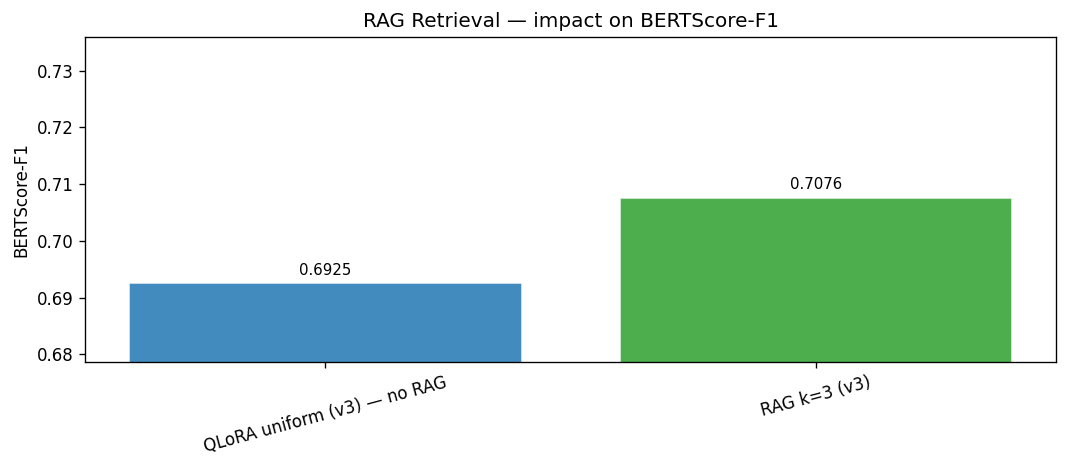

In [5]:
# Load baseline for comparison
baseline_v3 = json.loads((REPO_ROOT / 'reports' / 'eval_metrics_uniform_v3.json').read_text())

DISPLAY_NAMES = {
    'uniform_v3':       'QLoRA uniform (v3) — no RAG',
    'rag_k3_uniform_v3': 'RAG k=3 (v3)',
    'rag_k5_uniform_v3': 'RAG k=5 (v3)',
}

comparison = {'uniform_v3': baseline_v3, **rag_metrics}
rows = []
for variant, m in comparison.items():
    rows.append({
        'Model':             DISPLAY_NAMES.get(variant, variant),
        'BERTScore-F1':      round(m['bertscore_f1'],      4),
        'CheXbert micro-F1': round(m['chexbert_micro_f1'], 4),
        'CheXbert macro-F1': round(m['chexbert_macro_f1'], 4),
        'BLEU-4':            round(m['bleu4'],             4),
        'ROUGE-L':           round(m['rouge_l'],           4),
    })
display(pd.DataFrame(rows).set_index('Model'))

# Delta vs no-RAG baseline
print('\nΔ BERTScore vs no-RAG baseline:')
for variant, m in rag_metrics.items():
    delta = m['bertscore_f1'] - baseline_v3['bertscore_f1']
    print(f'  {DISPLAY_NAMES.get(variant, variant)}: {delta:+.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
names  = [DISPLAY_NAMES.get(v, v) for v in comparison]
bscore = [comparison[v]['bertscore_f1'] for v in comparison]
colors = ['#1f77b4'] + ['#2ca02c'] * len(rag_metrics)
bars   = ax.bar(names, bscore, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, bscore):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(min(bscore) * 0.98, max(bscore) * 1.04)
ax.set_ylabel('BERTScore-F1'); ax.set_title('RAG Retrieval — impact on BERTScore-F1')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_rag_comparison.png', dpi=150, bbox_inches='tight')
print('Saved eval_rag_comparison.png'); plt.show()

Estudios con retrieval exitoso : 586 / 600
Con al menos 1 label en común  : 249 (41.5%)
Jaccard promedio               : 0.181
Jaccard mediana                : 0.000

ΔBERTScore por cuartil de Jaccard (overlap de labels):
        mean   median  count
q                           
Q1  0.012192  0.00571    503
Q2  0.028972  0.01354     83
Saved rag_label_overlap_diagnostic.png


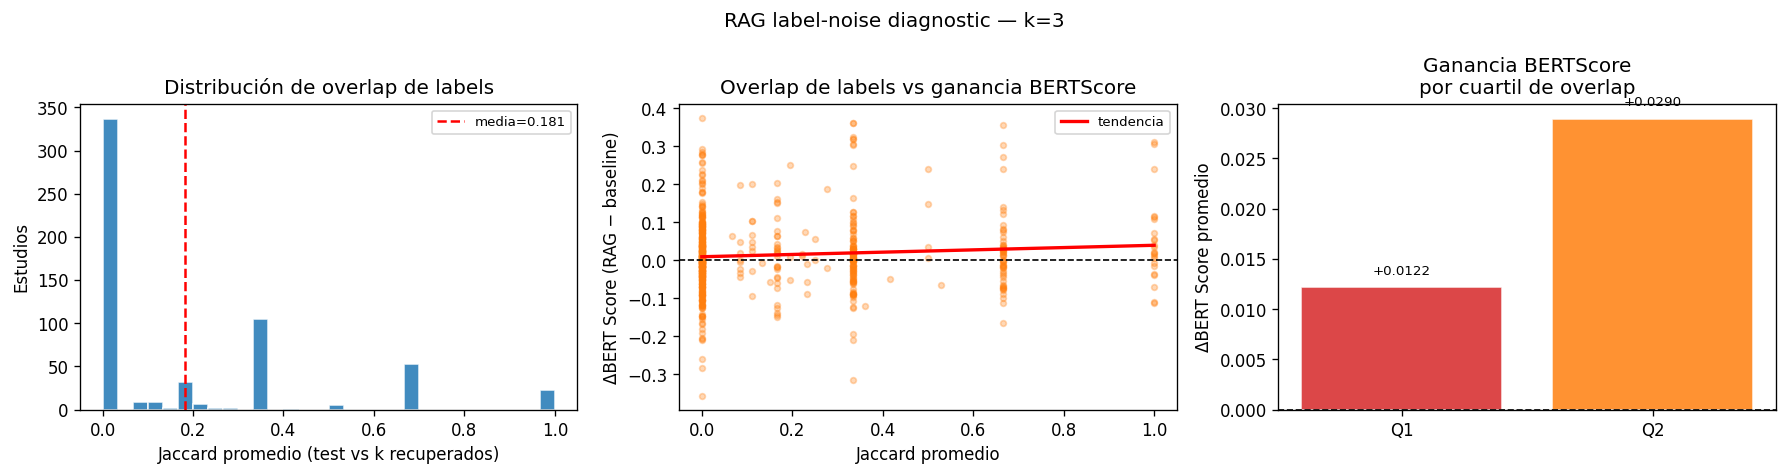


Split Jaccard ≥ 0.2:
  Alto overlap  (n=197): ΔBERT = +0.0233
  Bajo overlap  (n=389): ΔBERT = +0.0102

Hipótesis confirmada si: alto overlap → ΔBERT positivo, bajo overlap → ΔBERT negativo o plano.
Estudios con Jaccard = 0 (sin labels en común): 57.5%


In [6]:
# ── Diagnostic: ¿RAG recupera estudios con labels similares al test? ──────────
import warnings
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim_diag
from src.data.labels import CHEXBERT_LABELS

RAG_K_DIAG = 3  # debe coincidir con el k usado en STEP 3

# Verificar que los parquets tienen las columnas de labels
missing = [l for l in CHEXBERT_LABELS
           if l not in train_df.columns or l not in test_df.columns]
if missing:
    print(f'Faltan columnas de labels en parquet: {missing}')
    print('Corre label_dataframe() antes de continuar.')
else:
    train_lm = train_df[CHEXBERT_LABELS].values.astype(bool)
    test_lm  = test_df[CHEXBERT_LABELS].values.astype(bool)

    def _jaccard(a, b):
        inter = (a & b).sum()
        union = (a | b).sum()
        return float(inter / union) if union > 0 else 0.0

    # ── Por cada estudio de test: recuperar top-k y medir overlap de labels ──
    records = []
    for i, row in test_df.iterrows():
        indication = str(row.get('indication', '') or '').strip()
        if indication.lower() in {'nan', 'none', ''}: indication = ''

        test_vec = test_lm[i]

        if not indication:
            records.append({'idx': i, 'retrieved': False,
                            'mean_jaccard': 0.0, 'max_jaccard': 0.0,
                            'any_shared': False, 'max_sim': 0.0})
            continue

        q    = tfidf.transform([indication])
        sims = _cos_sim_diag(q, train_tfidf_matrix).flatten()
        top  = [j for j in sims.argsort()[::-1][:RAG_K_DIAG]
                if sims[j] >= MIN_SIM_THRESHOLD]

        if not top:
            records.append({'idx': i, 'retrieved': False,
                            'mean_jaccard': 0.0, 'max_jaccard': 0.0,
                            'any_shared': False, 'max_sim': 0.0})
            continue

        jaccards = [_jaccard(test_vec, train_lm[j]) for j in top]
        records.append({
            'idx':          i,
            'retrieved':    True,
            'mean_jaccard': float(np.mean(jaccards)),
            'max_jaccard':  float(np.max(jaccards)),
            'any_shared':   any(x > 0 for x in jaccards),
            'max_sim':      float(sims[top[0]]),
        })

    diag_df = pd.DataFrame(records)
    ret      = diag_df[diag_df['retrieved']]

    print(f'Estudios con retrieval exitoso : {diag_df["retrieved"].sum()} / {len(diag_df)}')
    print(f'Con al menos 1 label en común  : {diag_df["any_shared"].sum()} ({100*diag_df["any_shared"].mean():.1f}%)')
    print(f'Jaccard promedio               : {ret["mean_jaccard"].mean():.3f}')
    print(f'Jaccard mediana                : {ret["mean_jaccard"].median():.3f}')

    # ── Cargar deltas de BERTScore ────────────────────────────────────────────
    variant_key = f'rag_k{RAG_K_DIAG}_{RAG_VARIANT}'
    rag_path  = REPO_ROOT / 'reports' / f'eval_metrics_{variant_key}.json'
    base_path = REPO_ROOT / 'reports' / 'eval_metrics_uniform_v3.json'

    if not (rag_path.exists() and base_path.exists()):
        print('Faltan JSONs de métricas — corre STEP 4 primero.')
    else:
        rag_scores  = np.array(json.loads(rag_path.read_text())['bertscore_per_study'])
        base_scores = np.array(json.loads(base_path.read_text())['bertscore_per_study'])
        bert_delta  = rag_scores - base_scores

        diag_df['bert_delta'] = bert_delta[diag_df['idx'].values]
        ret = diag_df[diag_df['retrieved']].copy()

        # Cuartiles de overlap
                # Cuartiles de overlap — duplicates='drop' por el alto número de Jaccard=0
        ret['q'] = pd.qcut(ret['mean_jaccard'], q=4, duplicates='drop',
                           labels=False)
        q_labels = {i: f'Q{i+1}' for i in sorted(ret['q'].dropna().unique())}
        ret['q'] = ret['q'].map(q_labels)
        qsummary = ret.groupby('q', observed=True)['bert_delta'].agg(['mean', 'median', 'count'])
        print('\nΔBERTScore por cuartil de Jaccard (overlap de labels):')
        print(qsummary.to_string())

        # ── Plots ─────────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # 1. Distribución de Jaccard
        axes[0].hist(ret['mean_jaccard'], bins=30, color='#1f77b4',
                     alpha=0.85, edgecolor='white')
        axes[0].axvline(ret['mean_jaccard'].mean(), color='red',
                        linestyle='--', label=f'media={ret["mean_jaccard"].mean():.3f}')
        axes[0].set_xlabel('Jaccard promedio (test vs k recuperados)')
        axes[0].set_ylabel('Estudios')
        axes[0].set_title('Distribución de overlap de labels')
        axes[0].legend(fontsize=8)

        # 2. Scatter: Jaccard vs delta BERTScore
        axes[1].scatter(ret['mean_jaccard'], ret['bert_delta'],
                        alpha=0.3, s=12, color='#ff7f0e')
        axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            z = np.polyfit(ret['mean_jaccard'], ret['bert_delta'], 1)
            xr = np.linspace(ret['mean_jaccard'].min(), ret['mean_jaccard'].max(), 100)
            axes[1].plot(xr, np.poly1d(z)(xr), color='red', linewidth=2, label='tendencia')
        axes[1].set_xlabel('Jaccard promedio')
        axes[1].set_ylabel('ΔBERT Score (RAG − baseline)')
        axes[1].set_title('Overlap de labels vs ganancia BERTScore')
        axes[1].legend(fontsize=8)

        # 3. Barras por cuartil
        colors_q = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
        bars = axes[2].bar(qsummary.index, qsummary['mean'],
                           color=colors_q, alpha=0.85, edgecolor='white')
        axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
        for bar, val in zip(bars, qsummary['mean']):
            axes[2].text(bar.get_x() + bar.get_width()/2,
                         val + (0.001 if val >= 0 else -0.003),
                         f'{val:+.4f}', ha='center', va='bottom', fontsize=8)
        axes[2].set_ylabel('ΔBERT Score promedio')
        axes[2].set_title('Ganancia BERTScore\npor cuartil de overlap')

        plt.suptitle(f'RAG label-noise diagnostic — k={RAG_K_DIAG}', fontsize=12)
        plt.tight_layout()
        fig.savefig(FIGURES_DIR / 'rag_label_overlap_diagnostic.png',
                    dpi=150, bbox_inches='tight')
        print('Saved rag_label_overlap_diagnostic.png')
        plt.show()

        # ── Resumen split alto/bajo ──────────────────────────────────────────
        thr = 0.20
        hi  = ret[ret['mean_jaccard'] >= thr]
        lo  = ret[ret['mean_jaccard'] <  thr]
        print(f'\nSplit Jaccard ≥ {thr}:')
        print(f'  Alto overlap  (n={len(hi):3d}): ΔBERT = {hi["bert_delta"].mean():+.4f}')
        print(f'  Bajo overlap  (n={len(lo):3d}): ΔBERT = {lo["bert_delta"].mean():+.4f}')
        print()
        print('Hipótesis confirmada si: alto overlap → ΔBERT positivo, bajo overlap → ΔBERT negativo o plano.')
        zero_pct = (ret['mean_jaccard'] == 0).mean()
        print(f'Estudios con Jaccard = 0 (sin labels en común): {100*zero_pct:.1f}%')

,BERTScore-F1,CheXbert micro-F1,CheXbert macro-F1,BLEU-4,ROUGE-L
Condition,,,,,
v3 baseline (NB04 format),0.6925,0.4637,0.1651,0.1145,0.2915
v3 no-RAG (NB05 format),0.6879,0.4404,0.1445,0.1128,0.2852
RAG k=3 (v3),0.7076,0.3432,0.1160,0.1391,0.3051



Δ RAG k=3 vs baseline justo (NB05 format):
  BERTScore-F1          : +0.0198
  CheXbert micro-F1     : -0.0973
  CheXbert macro-F1     : -0.0284
  BLEU-4                : +0.0262
  ROUGE-L               : +0.0199


,v3 baseline,no-RAG (fair),RAG k=3,Δ (RAG − fair)
Label,,,,
Lung Lesion,0.000,0.000,0.133,0.133
Edema,0.000,0.000,0.000,0.000
Consolidation,0.000,0.000,0.000,0.000
Pneumonia,0.000,0.000,0.000,0.000
Pneumothorax,0.000,0.000,0.000,0.000
Pleural Effusion,0.308,0.286,0.160,-0.126
Pleural Other,0.000,0.000,0.000,0.000
Fracture,0.258,0.069,0.069,0.000
Support Devices,0.400,0.377,0.211,-0.166



Saved rag_fair_comparison.png


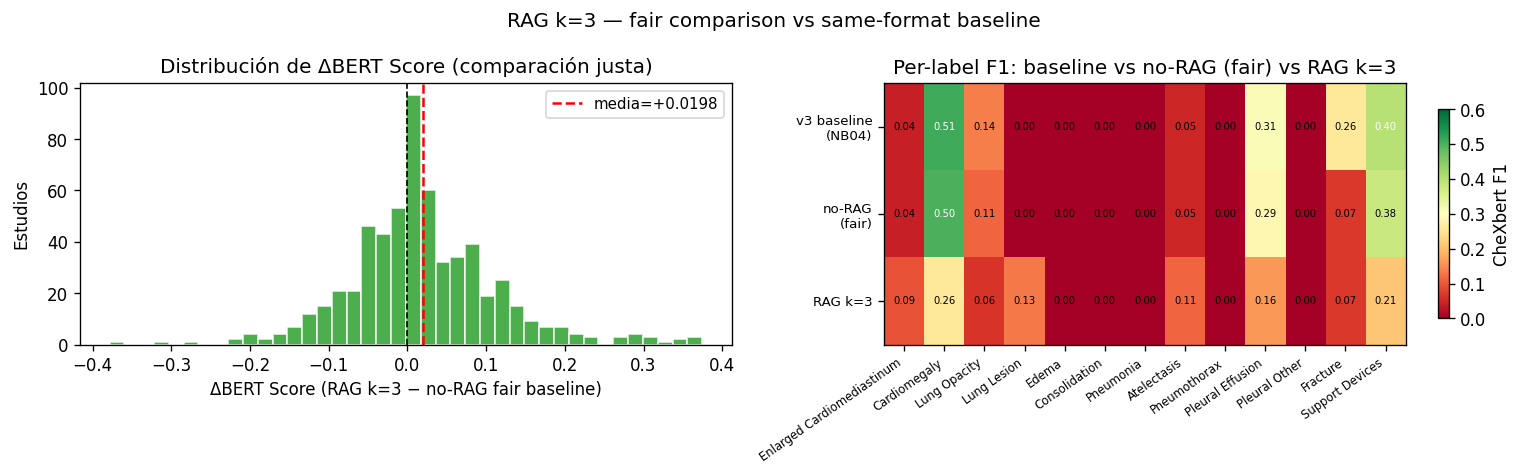

In [7]:
# ── Fair comparison RAG — carga el baseline justo ya computado en NB06 STEP 7 ─
import json
from pathlib import Path
from src.data.labels import CHEXBERT_LABELS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOHINT_PATH = REPO_ROOT / 'reports' / 'eval_metrics_nohint_uniform_v3.json'
RAG_PATH    = REPO_ROOT / 'reports' / f'eval_metrics_rag_k3_{RAG_VARIANT}.json'
NB04_PATH   = REPO_ROOT / 'reports' / 'eval_metrics_uniform_v3.json'

if not NOHINT_PATH.exists():
    print('No encontrado eval_metrics_nohint_uniform_v3.json')
    print('Corre NB06 STEP 7 primero — genera el mismo baseline justo para RAG.')
else:
    nohint = json.loads(NOHINT_PATH.read_text())
    rag    = json.loads(RAG_PATH.read_text())
    nb04   = json.loads(NB04_PATH.read_text()) if NB04_PATH.exists() else {}

    METRIC_KEY = {
        'BERTScore-F1':      'bertscore_f1',
        'CheXbert micro-F1': 'chexbert_micro_f1',
        'CheXbert macro-F1': 'chexbert_macro_f1',
        'BLEU-4':            'bleu4',
        'ROUGE-L':           'rouge_l',
    }

    # ── Tabla de 3 condiciones ────────────────────────────────────────────────
    three = {
        'v3 baseline (NB04 format)': nb04,
        'v3 no-RAG (NB05 format)':   nohint,
        'RAG k=3 (v3)':              rag,
    }
    rows = []
    for label, m in three.items():
        if not m: continue
        rows.append({'Condition': label,
                     **{col: round(m[key], 4) for col, key in METRIC_KEY.items()}})
    display(pd.DataFrame(rows).set_index('Condition'))

    # ── Deltas vs baseline justo ──────────────────────────────────────────────
    print('\nΔ RAG k=3 vs baseline justo (NB05 format):')
    for col, key in METRIC_KEY.items():
        delta = rag[key] - nohint[key]
        print(f'  {col:<22}: {delta:+.4f}')

    # ── Per-label F1 en labels raras ──────────────────────────────────────────
    RARE_LABELS = [l for l in CHEXBERT_LABELS
                   if l not in ('No Finding', 'Lung Opacity', 'Cardiomegaly',
                                'Enlarged Cardiomediastinum', 'Atelectasis')]

    rare_rows = []
    for label in RARE_LABELS:
        rare_rows.append({
            'Label':          label,
            'v3 baseline':    round(nb04.get('per_label_f1', {}).get(label, 0), 3),
            'no-RAG (fair)':  round(nohint['per_label_f1'].get(label, 0), 3),
            'RAG k=3':        round(rag['per_label_f1'].get(label, 0), 3),
        })
    rare_df = pd.DataFrame(rare_rows).set_index('Label')
    rare_df['Δ (RAG − fair)'] = (rare_df['RAG k=3'] - rare_df['no-RAG (fair)']).round(3)
    display(rare_df)

    # ── BERTScore per-study delta: RAG vs fair baseline ───────────────────────
    rag_scores    = np.array(rag['bertscore_per_study'])
    nohint_scores = np.array(nohint['bertscore_per_study'])
    delta         = rag_scores - nohint_scores

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histograma de deltas
    axes[0].hist(delta, bins=40, color='#2ca02c', alpha=0.85, edgecolor='white')
    axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[0].axvline(delta.mean(), color='red', linestyle='--',
                    label=f'media={delta.mean():+.4f}')
    axes[0].set_xlabel('ΔBERT Score (RAG k=3 − no-RAG fair baseline)')
    axes[0].set_ylabel('Estudios')
    axes[0].set_title('Distribución de ΔBERT Score (comparación justa)')
    axes[0].legend(fontsize=9)

    # Heatmap per-label: 3 condiciones
    plot_labels = [l for l in CHEXBERT_LABELS if l != 'No Finding']
    hm = np.array([
        [nb04.get('per_label_f1', {}).get(l, 0) for l in plot_labels],
        [nohint['per_label_f1'].get(l, 0) for l in plot_labels],
        [rag['per_label_f1'].get(l, 0) for l in plot_labels],
    ])
    im = axes[1].imshow(hm, cmap='RdYlGn', vmin=0, vmax=0.6, aspect='auto')
    axes[1].set_xticks(range(len(plot_labels)))
    axes[1].set_xticklabels(plot_labels, rotation=35, ha='right', fontsize=7)
    axes[1].set_yticks(range(3))
    axes[1].set_yticklabels(['v3 baseline\n(NB04)', 'no-RAG\n(fair)', 'RAG k=3'], fontsize=8)
    for i in range(3):
        for j in range(len(plot_labels)):
            axes[1].text(j, i, f'{hm[i,j]:.2f}', ha='center', va='center',
                         fontsize=6, color='black' if hm[i,j] < 0.4 else 'white')
    plt.colorbar(im, ax=axes[1], shrink=0.8, label='CheXbert F1')
    axes[1].set_title('Per-label F1: baseline vs no-RAG (fair) vs RAG k=3')

    plt.suptitle('RAG k=3 — fair comparison vs same-format baseline', fontsize=12)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'rag_fair_comparison.png', dpi=150, bbox_inches='tight')
    print('\nSaved rag_fair_comparison.png')
    plt.show()

## Done

Metrics written to `reports/eval_metrics_rag_k*_uniform_v3.json`.  
**Next:** run notebook 06 (association rules), then return to notebook 04 STEP 7 for the grand comparison.